In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving test_no_label.csv to test_no_label.csv
Saving train_c.csv to train_c.csv
Saving val.csv to val.csv


In [3]:
train = pd.read_csv("train_c.csv")
val = pd.read_csv("val.csv")
test = pd.read_csv("test_no_label.csv")

print(train.shape)
print(val.shape)
print(test.shape)


(7589, 18)
(3536, 18)
(3403, 17)


In [4]:
train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class,id
0,23562,612.084,0.000000,122.512653,2.010000,0.867457,23959,173.205283,0.698257,0.983430,0.790315,0.703370,0.010451,0.001578,0.494730,0.994407,DERMASON,0
1,-36424,717.948,275.400182,168.756112,1.631942,0.790264,36768,215.351984,0.681791,0.990644,0.887997,0.781960,0.007561,0.001744,0.611462,0.997870,DERMASON,1
2,-37903,727.708,273.195588,177.348275,1.540447,0.760650,38267,219.680674,0.766182,0.990488,0.899434,0.804115,0.007208,0.001859,0.646601,0.996054,SIRA,2
3,82619,1114.990,442.418929,239.709011,1.845650,0.840498,83605,324.335903,0.808500,0.988206,0.835118,0.733097,0.005355,0.000954,0.537431,0.991909,CALI,3
4,33423,659.036,224.168053,189.981080,1.179949,0.530805,33707,206.289809,0.772983,0.991574,0.967023,0.920246,0.006707,0.002967,0.846853,0.999244,SEKER,4


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7589 entries, 0 to 7588
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             7589 non-null   int64  
 1   Perimeter        7589 non-null   float64
 2   MajorAxisLength  7589 non-null   float64
 3   MinorAxisLength  7589 non-null   float64
 4   AspectRation     7589 non-null   float64
 5   Eccentricity     7589 non-null   float64
 6   ConvexArea       7589 non-null   int64  
 7   EquivDiameter    7589 non-null   float64
 8   Extent           7589 non-null   float64
 9   Solidity         7589 non-null   float64
 10  roundness        7589 non-null   float64
 11  Compactness      7589 non-null   float64
 12  ShapeFactor1     7589 non-null   float64
 13  ShapeFactor2     7589 non-null   float64
 14  ShapeFactor3     7589 non-null   float64
 15  ShapeFactor4     7589 non-null   float64
 16  Class            7589 non-null   object 
 17  id            

In [6]:
train.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,id
count,7589.00000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000,7589.000000
mean,42577.11912,855.427398,304.328146,202.355417,1.582963,0.751062,53887.227039,253.163509,0.749890,0.987187,0.873612,0.799867,0.006567,0.001716,0.643555,0.995102,3794.000000
std,43669.70026,216.996666,109.641948,45.693510,0.245005,0.091533,30343.698394,60.033764,0.048621,0.004626,0.059058,0.061387,0.001140,0.000595,0.098507,0.004376,2190.899929
min,-230867.00000,524.736000,0.000000,122.512653,1.049424,0.303273,20684.000000,161.243764,0.566669,0.943559,0.571801,0.640577,0.002778,0.000564,0.410339,0.949990,0.000000
25%,33418.00000,703.568000,248.868231,175.466484,1.432982,0.716248,36663.000000,214.961414,0.718616,0.985741,0.833570,0.762765,0.005900,0.001157,0.581811,0.993797,1897.000000
50%,42490.00000,794.308000,290.557350,192.221690,1.553338,0.765215,45105.000000,238.176226,0.759709,0.988301,0.883375,0.800690,0.006652,0.001693,0.641105,0.996424,3794.000000
75%,58200.00000,975.344000,372.954622,217.107222,1.706102,0.810216,62010.000000,278.892328,0.786873,0.990033,0.916599,0.834178,0.007286,0.002166,0.695852,0.997869,5691.000000
max,254616.00000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.858420,0.994677,0.987920,0.975595,0.010451,0.003564,0.951785,0.999733,7588.000000


###Check Class Values

In [7]:
train["Class"].value_counts()


,count
Class,
DERMASON,1997
SIRA,1462
SEKER,1132
HOROZ,1063
CALI,887
BARBUNYA,739
BOMBAY,309


### 7 Class types DERMASON, SIRA, SEKER, HOROZ, CALI, BARBUNYA, BOMBAY

### **EDA Part**

### 1: Checking for null values

In [8]:
train.isnull().sum()


,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [9]:
test.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [10]:
val.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


#### Zero Nulls

### 2: Class Distribution

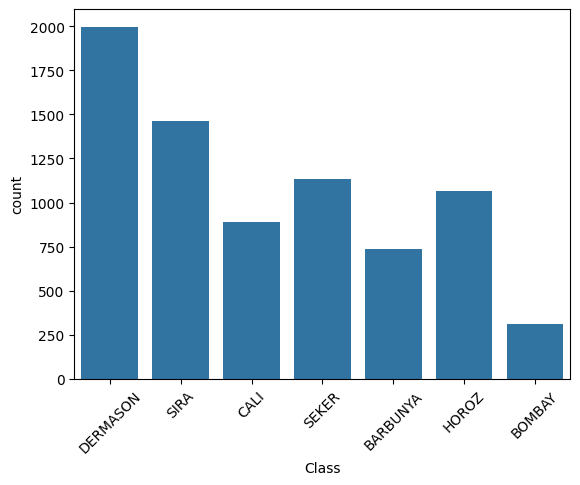

In [11]:
sns.countplot(x=train["Class"])
plt.xticks(rotation=45)
plt.show()

### 3: Correlation Matrix

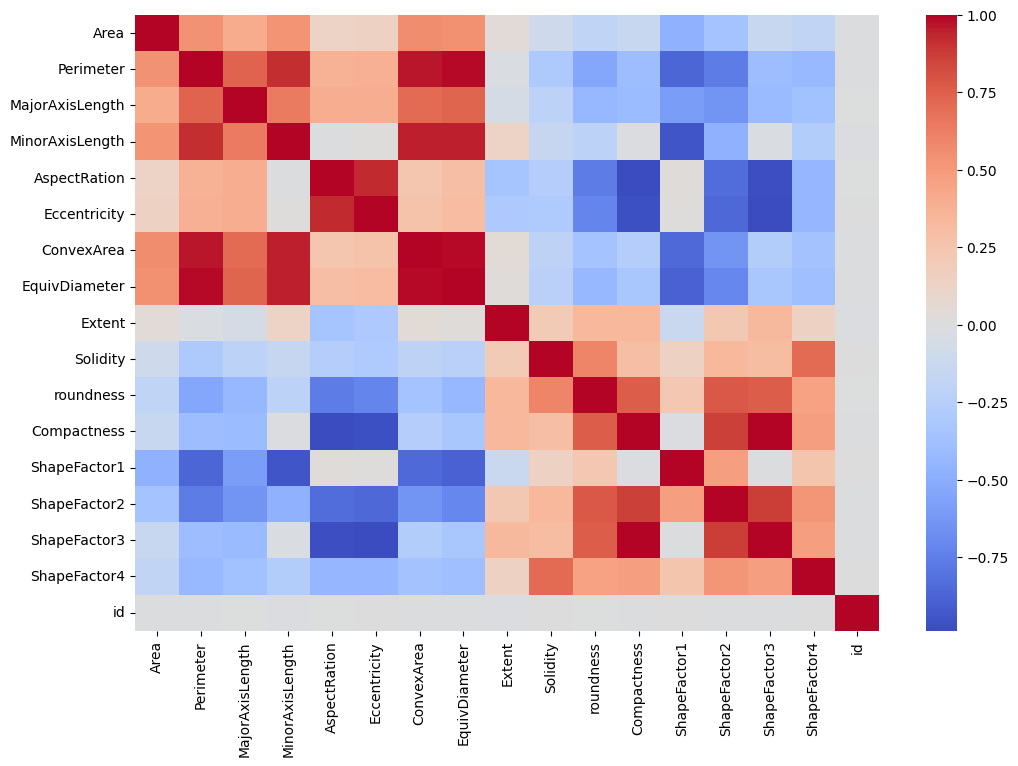

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.drop(columns=["Class"]).corr(),
    cmap="coolwarm"
)

plt.show()

###4: Feature Histograms
####skewness

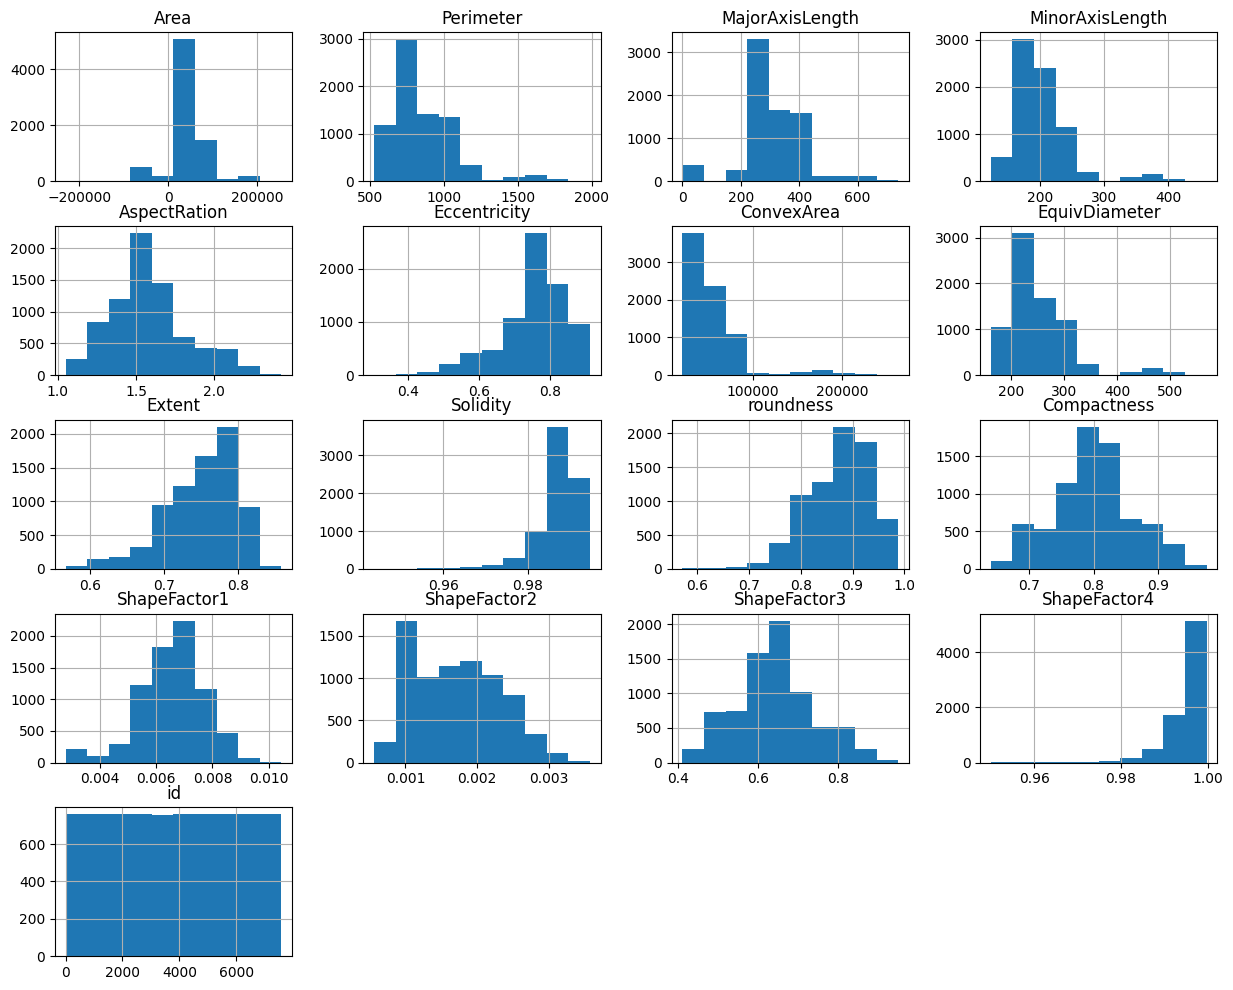

In [13]:
train.hist(figsize=(15,12))
plt.show()

### 5: Boxplots for Outliers

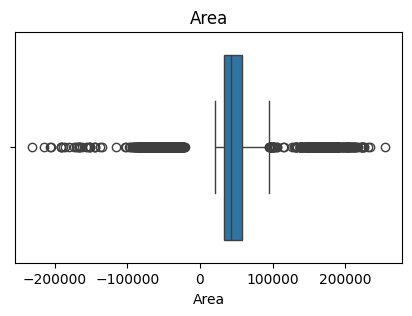

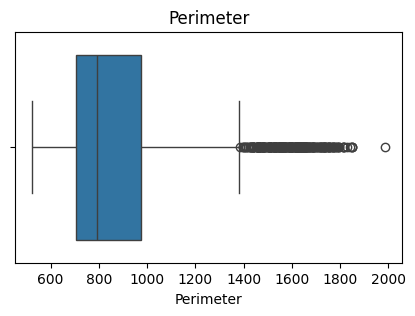

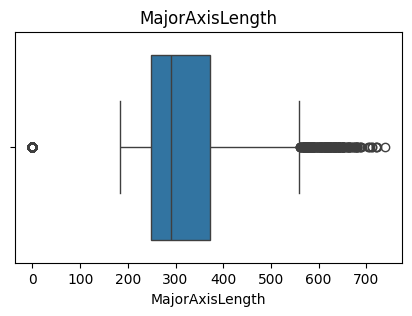

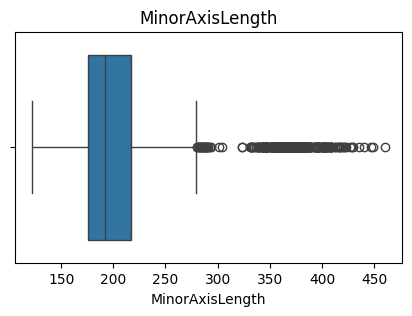

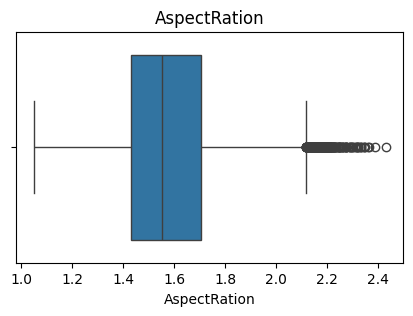

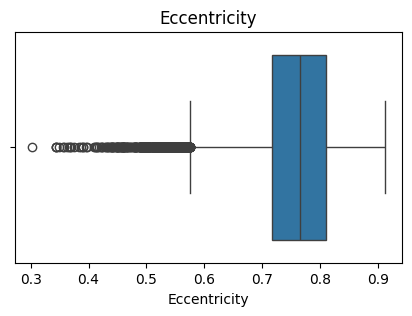

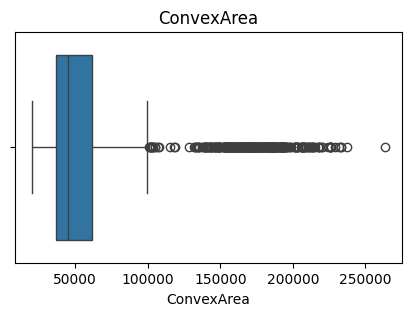

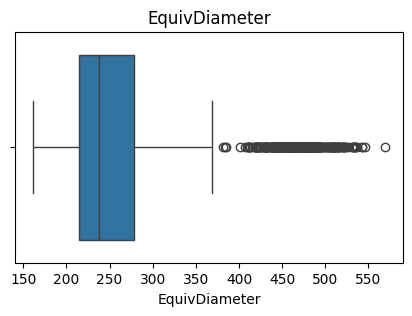

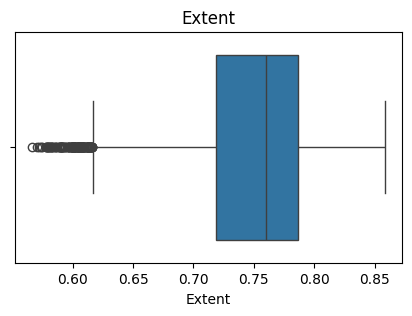

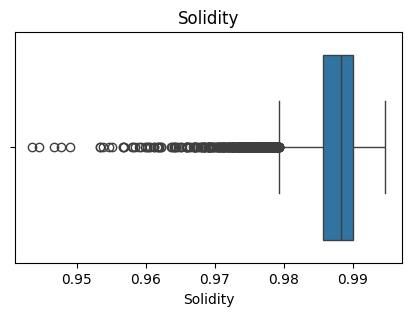

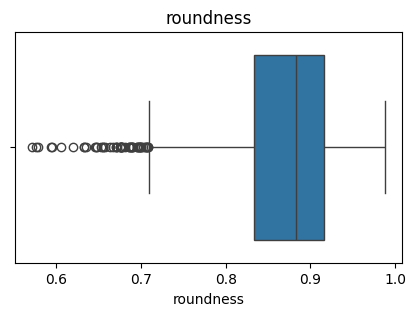

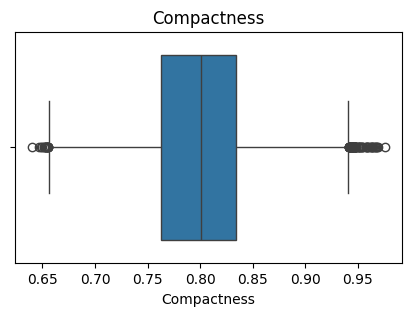

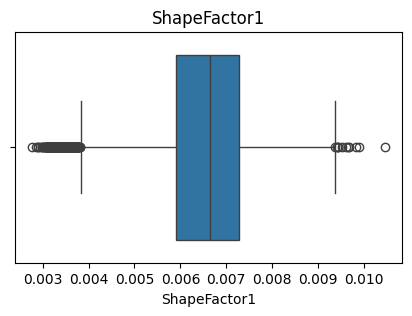

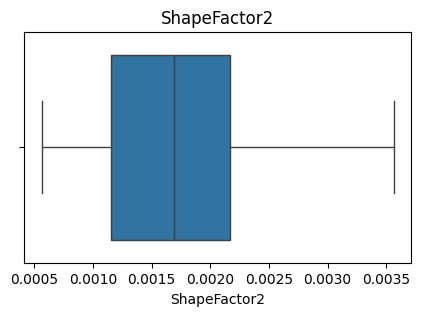

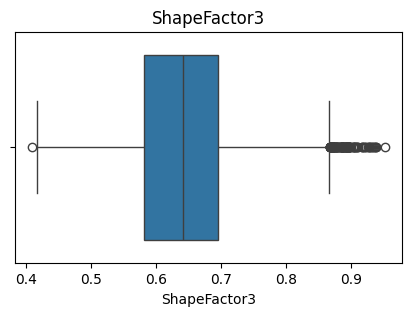

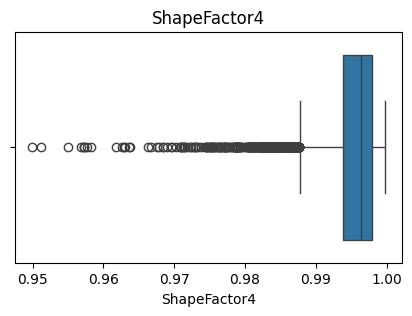

In [14]:
for col in train.columns[:-2]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

###6: Remove ID Column

In [15]:
train.drop("id", axis=1, inplace=True)
val.drop("id", axis=1, inplace=True)

test_ids = test["id"]

test.drop("id", axis=1, inplace=True)

###7:Handle Negative Values

In [16]:
numeric_cols = train.select_dtypes(include=np.number).columns

for col in numeric_cols:
    train[col] = train[col].abs()
    val[col] = val[col].abs()
    test[col] = test[col].abs()

###8:**Encode** Target Labels

In [17]:

encoder = LabelEncoder()

train["Class"] = encoder.fit_transform(train["Class"])
val["Class"] = encoder.transform(val["Class"])

###9:**Separate** Features and Labels

In [18]:
X_train = train.drop("Class", axis=1)
y_train = train["Class"]

X_val = val.drop("Class", axis=1)
y_val = val["Class"]

###10:**Feature** Scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(test)

###11:Baseline Model

#####A)Random Forest

In [20]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

pred = rf.predict(X_val_scaled)

print("Accuracy:")
print(accuracy_score(y_val, pred))

Accuracy:
0.931843891402715


#####B)Classification Report

In [21]:
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       353
           1       1.00      1.00      1.00       122
           2       0.95      0.95      0.95       421
           3       0.93      0.93      0.93       926
           4       0.96      0.96      0.96       539
           5       0.95      0.95      0.95       514
           6       0.88      0.87      0.88       661

    accuracy                           0.93      3536
   macro avg       0.94      0.94      0.94      3536
weighted avg       0.93      0.93      0.93      3536



#####C)Confusion Matrix

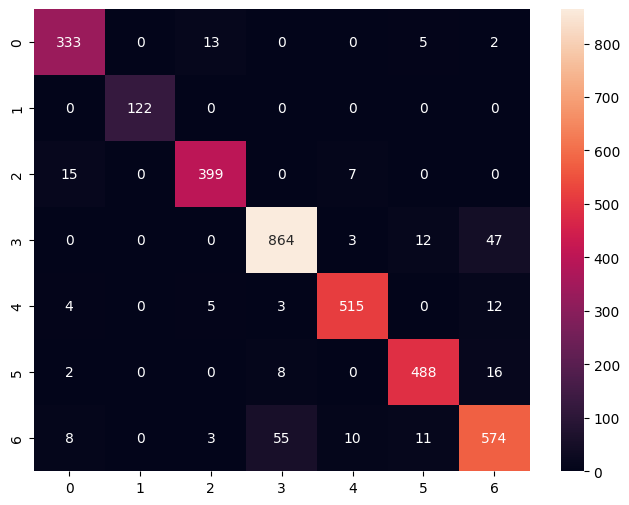

In [22]:
cm = confusion_matrix(y_val, pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

###12:Improved Models

######Model 1: Random Forest

In [23]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

#####Model 2: Gradient Boosting

In [24]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

#####Model 3: XGBoost (Recommended)

In [25]:
!pip install xgboost

In [26]:
from xgboost import XGBClassifier

In [27]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=7,
    random_state=42
)

###TRAIN

In [28]:
xgb.fit(X_train_scaled, y_train)

pred = xgb.predict(X_val_scaled)

print(accuracy_score(y_val, pred))

0.9346719457013575


###13:Hyperparameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV

In [30]:
params = {
    "n_estimators":[200,300,500],
    "max_depth":[4,6,8]
}

In [31]:
grid = GridSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=7
    ),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

{'max_depth': 8, 'n_estimators': 300}


#####Getting Best Model

In [32]:
best_model = grid.best_estimator_

#####Best Validation set:

In [33]:
from sklearn.metrics import accuracy_score

pred = best_model.predict(X_val_scaled)

accuracy = accuracy_score(y_val, pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9321266968325792


#####Classification Report

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       353
           1       0.98      1.00      0.99       122
           2       0.95      0.95      0.95       421
           3       0.92      0.93      0.93       926
           4       0.96      0.96      0.96       539
           5       0.96      0.94      0.95       514
           6       0.87      0.87      0.87       661

    accuracy                           0.93      3536
   macro avg       0.94      0.94      0.94      3536
weighted avg       0.93      0.93      0.93      3536



#####Confusion Matrix

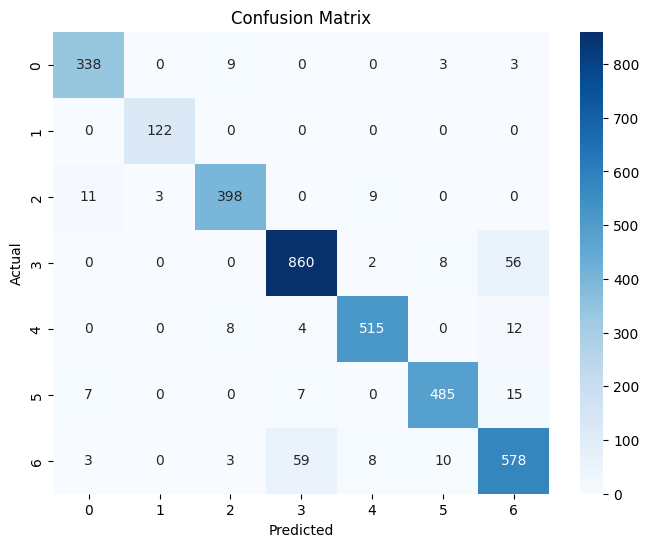

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#####Feature Importance

In [36]:
importances = best_model.feature_importances_

In [37]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
11,Compactness,0.260185
6,ConvexArea,0.189517
0,Area,0.181438
12,ShapeFactor1,0.079034
1,Perimeter,0.053595
4,AspectRation,0.052168
2,MajorAxisLength,0.042761
13,ShapeFactor2,0.039970
3,MinorAxisLength,0.039854
10,roundness,0.034111


#####Top Features

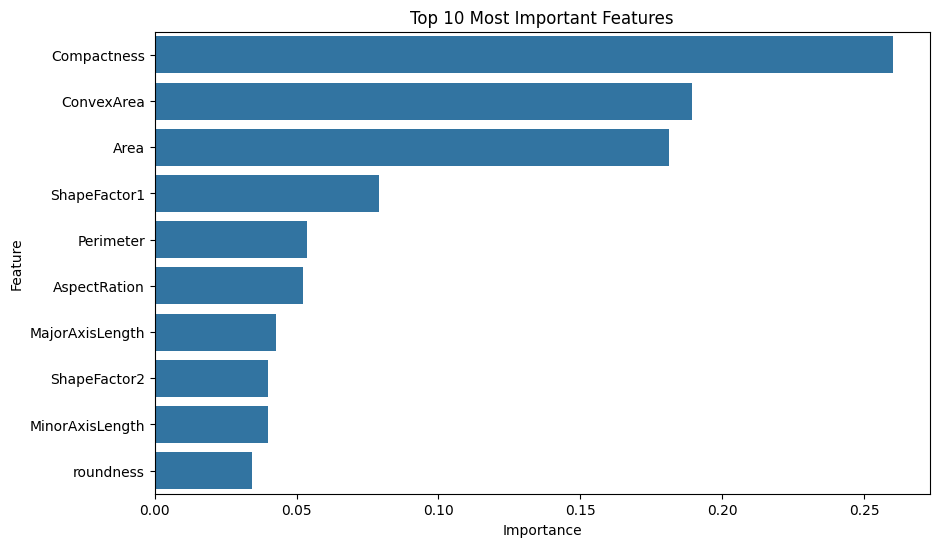

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Most Important Features")

plt.show()

#####Training on all data

In [39]:
X_full = pd.concat([X_train, X_val])

y_full = pd.concat([y_train, y_val])

In [40]:
X_full_scaled = scaler.fit_transform(X_full)

X_test_scaled = scaler.transform(test)

###15:Train Final Model

In [41]:
best_model.fit(
    X_full_scaled,
    y_full
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=7, ...)

###16: Predict Competition Test Data

In [42]:
test_predictions = best_model.predict(
    X_test_scaled
)

###17: Create Submission File

In [43]:
submission = pd.DataFrame({
    'id': test_ids,
    'Class': test_predictions
})

##### Add Labels back


In [44]:
mapping = {
    0: 'BARBUNYA',
    1: 'BOMBAY',
    2: 'CALI',
    3: 'DERMASON',
    4: 'HOROZ',
    5: 'SEKER',
    6: 'SIRA'
}

submission["Class"] = submission["Class"].map(mapping)

In [45]:
submission.head()

,id,Class
0,0,CALI
1,1,DERMASON
2,2,DERMASON
3,3,SIRA
4,4,SEKER


In [46]:
submission.to_csv(
    "submission.csv",
    index=False
)

In [48]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

YOUSSEF ESLAM HUSSEIN | 231000070

YOUSSEF KHALID HASHEM | 231000337

ELHASSAN MAHMOUD      | 231013315

OMAR MOHMED ELSANHOURY| 231000141